In [45]:
# Importamos las librerías necesarias para la manipulación de datos, el modelado y la evaluación de modelos de clasificación.
# Estas incluyen pandas para el manejo de datos, scikit-learn para la creación y evaluación de modelos, y matplotlib para la visualización de resultados.

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [46]:
# Cargamos el conjunto de datos desde un archivo CSV utilizando pandas. Este conjunto de datos se utilizará para entrenar y evaluar los modelos de clasificación.

dataset = pd.read_csv(
    "../dataset.csv"
)

dataset.head()

,rms,peak,crest,kurtosis,dominant_freq,dominant_amp,label
0,0.000000,0.0,0.000000,0.000000,0,0.0,normal
1,6959.322842,10709.0,1.538799,-1.805022,0,5488485.0,normal
2,9065.489082,10989.0,1.212179,-0.537914,0,9224760.0,normal
3,8074.572185,11014.0,1.364035,0.261661,0,7798694.0,normal
4,7413.079071,11325.0,1.527705,-1.522515,0,6914081.0,normal


In [47]:
# Separamos las características (X) de la variable objetivo (y).
# La variable objetivo es la columna "label", que contiene las etiquetas de clase para cada muestra. Las características son todas las demás columnas del conjunto de datos.
# Esto nos permitirá entrenar los modelos de clasificación utilizando las características para predecir las etiquetas de clase.

X = dataset.drop(
    "label",
    axis=1
)

y = dataset["label"]

In [48]:
# Dividimos el conjunto de datos en conjuntos de entrenamiento y prueba utilizando la función train_test_split de scikit-learn.
# El 80% de los datos se utilizará para entrenar los modelos, mientras que el 20% restante se utilizará para evaluar su rendimiento.
# La división se realiza de manera estratificada para asegurar que la proporción de clases en el conjunto de entrenamiento y prueba sea similar a la del conjunto de datos original.
# El parámetro random_state se establece en 42 para garantizar la reproducibilidad de los resultados.
# Esto nos permitirá evaluar el rendimiento de los modelos de clasificación en datos no vistos durante el entrenamiento.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [49]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [50]:
print(dataset.isna().sum())

rms              0
peak             0
crest            0
kurtosis         0
dominant_freq    0
dominant_amp     0
label            0
dtype: int64


In [51]:
# Entrenamos un modelo de clasificación utilizando el algoritmo Random Forest.
# Este modelo se compone de múltiples árboles de decisión que trabajan juntos para mejorar la precisión de las predicciones.
# El número de árboles se establece en 100, lo que suele ser un buen punto de partida para obtener un rendimiento sólido sin incurrir en un tiempo de entrenamiento excesivo.
# El parámetro random_state se establece en 42 para garantizar la reproducibilidad de los resultados.
# Después de entrenar el modelo, realizamos predicciones en el conjunto de prueba para evaluar su rendimiento.
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

pred_rf = rf.predict(
    X_test
)

In [52]:
print("Random Forest")
print(classification_report(y_test, pred_rf))

Random Forest
               precision    recall  f1-score   support

       normal       0.40      0.29      0.33         7
unbalance_19g       0.50      0.71      0.59         7
unbalance_23g       0.67      0.29      0.40         7
unbalance_27g       0.40      0.57      0.47         7

     accuracy                           0.46        28
    macro avg       0.49      0.46      0.45        28
 weighted avg       0.49      0.46      0.45        28



In [53]:
print("SVM")
print(classification_report(y_test, pred_svm))

SVM
               precision    recall  f1-score   support

       normal       0.57      0.57      0.57         7
unbalance_19g       0.50      0.71      0.59         7
unbalance_23g       0.67      0.29      0.40         7
unbalance_27g       0.38      0.43      0.40         7

     accuracy                           0.50        28
    macro avg       0.53      0.50      0.49        28
 weighted avg       0.53      0.50      0.49        28



In [54]:
# Calculamos la precisión del modelo Random Forest utilizando la función accuracy_score de scikit-learn, que compara las etiquetas verdaderas (y_test) con las etiquetas predichas (pred_rf).
# La precisión es una métrica que indica el porcentaje de predicciones correctas realizadas por el modelo en el conjunto de prueba.

acc_rf = accuracy_score(
    y_test,
    pred_rf
)

print(acc_rf)

0.4642857142857143


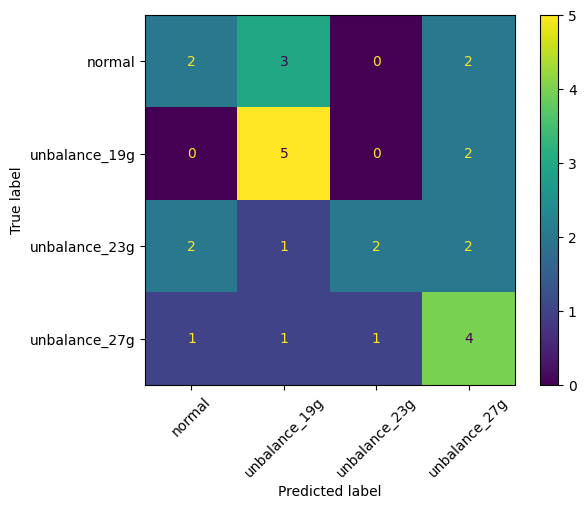

In [55]:
# Generamos un informe de clasificación utilizando la función classification_report de scikit-learn, que proporciona métricas detalladas como precisión, recall y F1-score para cada clase.
# Esto nos permitirá evaluar el rendimiento del modelo en cada clase individualmente y entender mejor dónde el modelo puede estar cometiendo errores.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_rf,
    xticks_rotation=45
)

plt.show()

In [56]:
# Imprimimos el informe de clasificación para el modelo Random Forest,
# que incluye métricas como precisión, recall y F1-score para cada clase, así como el soporte (número de muestras) para cada clase.


print(
    classification_report(
        y_test,
        pred_rf
    )
)

               precision    recall  f1-score   support

       normal       0.40      0.29      0.33         7
unbalance_19g       0.50      0.71      0.59         7
unbalance_23g       0.67      0.29      0.40         7
unbalance_27g       0.40      0.57      0.47         7

     accuracy                           0.46        28
    macro avg       0.49      0.46      0.45        28
 weighted avg       0.49      0.46      0.45        28



In [57]:
# Entrenamos un modelo de clasificación utilizando el algoritmo Support Vector Machine (SVM).
# SVM es un algoritmo de clasificación que encuentra el hiperplano óptimo que separa las clases en el espacio de características.
# Después de entrenar el modelo, realizamos predicciones en el conjunto de prueba para evaluar su rendimiento.

svm = SVC()

svm.fit(
    X_train,
    y_train
)

pred_svm = svm.predict(
    X_test
)

acc_svm = accuracy_score(
    y_test,
    pred_svm
)

print(acc_svm)

0.5


In [58]:
results = pd.DataFrame({
    "Modelo":[
        "Random Forest",
        "SVM"
    ],
    "Accuracy":[
        acc_rf,
        acc_svm
    ]
})

results

,Modelo,Accuracy
0,Random Forest,0.464286
1,SVM,0.500000


### Se desarrolló un sistema de clasificación de condiciones de operación utilizando señales de vibración. Las señales fueron segmentadas en ventanas y se extrajeron características estadísticas y espectrales. Se entrenaron modelos Random Forest y SVM, obteniéndose una clasificación multiclase de las condiciones Normal, Unbalance 19 g, Unbalance 23 g y Unbalance 27 g. El modelo con mayor accuracy fue seleccionado como modelo final.

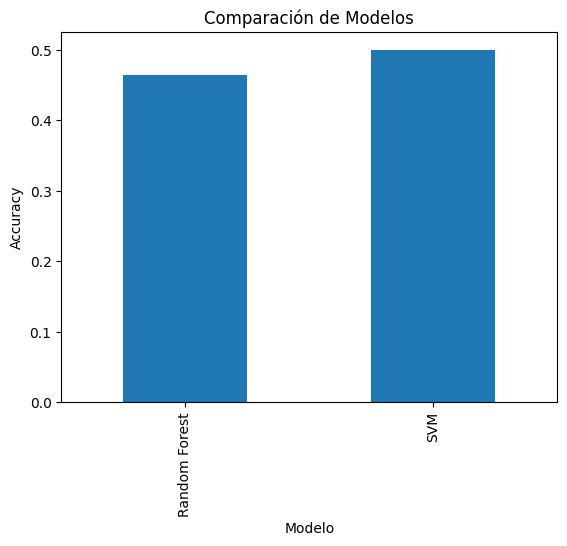

In [59]:
results = pd.DataFrame({
    "Modelo": ["Random Forest", "SVM"],
    "Accuracy": [acc_rf, acc_svm]
})

results.plot(
    x="Modelo",
    y="Accuracy",
    kind="bar",
    legend=False
)

plt.ylabel("Accuracy")
plt.title("Comparación de Modelos")

plt.show()

In [60]:
print(acc_rf)
print(acc_svm)

0.4642857142857143
0.5
